# Clustering

## 0. Data Prep

In [1]:
# read in the data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../Data/entertainment_clean.csv')
df.head()

,name,books,tv_shows,video_games
0,Aaliyah,0.5,4.6,4.9
1,Abigail,0.0,4.5,4.8
2,Addison,0.5,4.5,5.0
3,Adeline,3.5,4.5,6.6
4,Alana,2.8,3.8,5.6


In [2]:
# note the number of rows and columns
df.shape

(150, 4)

In [3]:
# check 1: is the data at the right row granularity? yes, each row is a student
df.name.nunique()

150

In [4]:
# check 2: are the columns non-null?
df[df.isna().any(axis=1)]

,name,books,tv_shows,video_games


In [5]:
# check 3: are the columns numeric?
df.dtypes

name            object
books          float64
tv_shows       float64
video_games    float64
dtype: object

In [6]:
# check 4: engineer new features? not for now.

In [7]:
# check 5: select features? exclude the name column for modeling.
data = df.drop(columns='name')
data.head()

,books,tv_shows,video_games
0,0.5,4.6,4.9
1,0.0,4.5,4.8
2,0.5,4.5,5.0
3,3.5,4.5,6.6
4,2.8,3.8,5.6


In [8]:
# check 6: scale features? data is roughly all on a similar scale (for a distance-based calculation)
data.describe()

,books,tv_shows,video_games
count,150.000000,150.000000,150.000000
mean,2.993333,4.586000,5.843333
std,1.917761,0.645587,0.828066
min,0.000000,3.000000,4.300000
25%,0.800000,4.200000,5.100000
50%,3.200000,4.500000,5.800000
75%,4.500000,4.900000,6.400000
max,6.200000,6.600000,7.900000


In [9]:
# the dataframe is ready for modeling!
data.head()

,books,tv_shows,video_games
0,0.5,4.6,4.9
1,0.0,4.5,4.8
2,0.5,4.5,5.0
3,3.5,4.5,6.6
4,2.8,3.8,5.6


## 1. Fit a K-Means Model

### i. K-Means Basics

In [10]:
# import kmeans from sklearn
from sklearn.cluster import KMeans

In [11]:
# fit a kmeans model with 2 clusters
kmeans2 = KMeans(n_clusters=2, n_init='auto', random_state=42)
kmeans2.fit(data)

C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [12]:
# view the cluster labels
kmeans2.labels_

array([0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0], dtype=int32)

### ii. Visualizing K-Means Clustering

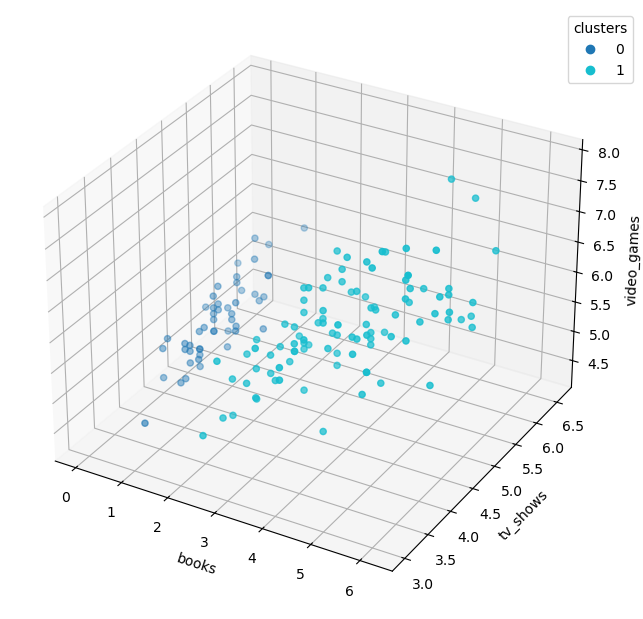

In [13]:
# import plotting library
from mpl_toolkits.mplot3d import Axes3D

# combine the data and cluster labels
cluster_labels = pd.Series(kmeans2.labels_, name='cluster')

# create a clean dataframe
df_clean = pd.concat([data, cluster_labels], axis=1)

# create a 3d scatter plot
fig = plt.figure(figsize=(8, 6))
ax = Axes3D(fig)
fig.add_axes(ax)

# specify the data and labels
sc = ax.scatter(df_clean['books'], df_clean['tv_shows'], df_clean['video_games'],
                c=df_clean['cluster'], cmap='tab10')
ax.set_xlabel('books')
ax.set_ylabel('tv_shows')
ax.set_zlabel('video_games')

# add a legend
plt.legend(*sc.legend_elements(), title='clusters',
           bbox_to_anchor=(1.05, 1));

### iii. Interpreting K-Means Clustering

In [14]:
# view the column names
data.columns

Index(['books', 'tv_shows', 'video_games'], dtype='object')

In [15]:
# view the cluster centers
kmeans2.cluster_centers_

array([[0.596, 5.13 , 5.006],
       [4.192, 4.314, 6.262]])

In [16]:
# check the mean of each column
data.mean()

books          2.993333
tv_shows       4.586000
video_games    5.843333
dtype: float64

Students in **Cluster 1** spend, on average:
* 0.6 hours reading books
* 5.1 hours watching tv shows
* 5 hours playing video games

Students in **Cluster 2** spend, on average:
* 4.2 hours reading books
* 4.3 hours watching tv shows 
* 6.3 hours playing video games

Let's name the clusters:
* Cluster 1: **Non-readers**
* Cluster 2: **Entertainment enthusiasts**

In [17]:
# fit a kmeans model with 3 clusters
kmeans3 = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans3.fit(data)

C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [18]:
# view the cluster labels
kmeans3.labels_

array([0, 0, 0, 2, 2, 1, 1, 2, 0, 2, 1, 0, 0, 0, 0, 0, 2, 0, 1, 1, 2, 2,
       2, 1, 2, 1, 0, 0, 0, 1, 2, 1, 1, 1, 1, 2, 2, 0, 0, 1, 2, 2, 0, 0,
       1, 2, 0, 1, 0, 1, 1, 1, 2, 2, 2, 1, 0, 1, 2, 2, 0, 0, 0, 2, 1, 1,
       0, 2, 1, 2, 1, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 0, 0, 0, 2, 2, 0,
       0, 2, 0, 2, 2, 2, 2, 1, 2, 1, 2, 0, 1, 0, 2, 2, 1, 2, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 2, 0, 1, 2, 2, 1, 0, 0, 0, 1, 2, 2, 2, 0, 0, 0,
       1, 0, 2, 1, 1, 1, 1, 2, 0, 0, 2, 1, 2, 1, 1, 1, 0, 0], dtype=int32)

In [19]:
# view the cluster centers
kmeans3.cluster_centers_

array([[0.596     , 5.13      , 5.006     ],
       [5.14375   , 4.52708333, 6.63958333],
       [3.31346154, 4.11730769, 5.91346154]])

In [20]:
# view the cluster centers in a dataframe
cluster_centers3 = pd.DataFrame(kmeans3.cluster_centers_, columns=data.columns)
cluster_centers3

,books,tv_shows,video_games
0,0.596000,5.130000,5.006000
1,5.143750,4.527083,6.639583
2,3.313462,4.117308,5.913462


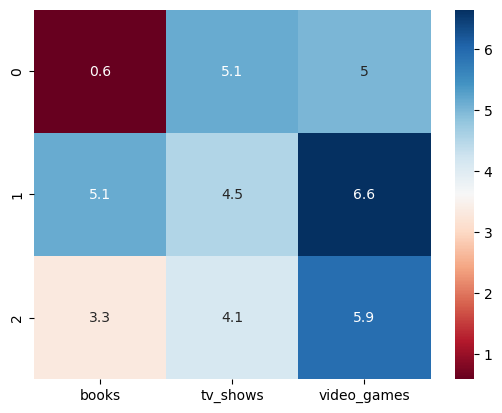

In [21]:
# view the cluster centers in a heatmap
import seaborn as sns
sns.heatmap(cluster_centers3, cmap='RdBu', annot=True);

Name the clusters:

* Cluster 0: **Non-readers**
* Cluster 1: **Entertainment enthusiasts**
* Cluster 2: **Prefer video games to books**

## 2. Inertia Plot

In [22]:
# view previous inertia values
kmeans2.inertia_, kmeans3.inertia_

(206.442, 105.47568525641029)

In [23]:
# create an empty list to hold many inertia values
inertia_values = []

# create 2 - 15 clusters, and add the intertia scores to the list
for k in range(2, 16):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(data)
    inertia_values.append(kmeans.inertia_)

C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have

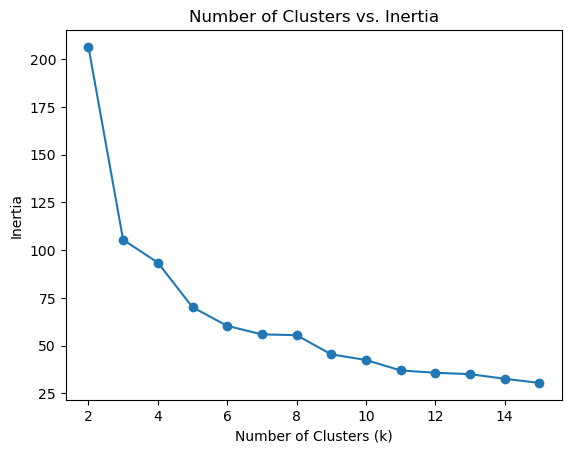

In [24]:
# plot the inertia values

# turn the list into a series for plotting
inertia_series = pd.Series(inertia_values, index=range(2, 16))

# plot the data
inertia_series.plot(marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Number of Clusters vs. Inertia");

**Insight from the inertia plot**: 3 and 5 clusters both seem to be elbows - let's dive into both of them

Remember our 3 clusters:

* Cluster 0: **Non-readers**
* Cluster 1: **Entertainment enthusiasts**
* Cluster 2: **Prefer video games to books**

In [25]:
# now for 5 clusters
kmeans5 = KMeans(n_clusters=5, n_init='auto', random_state=42)
kmeans5.fit(data)

C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [26]:
# view the cluster centers in a dataframe
cluster_centers5 = pd.DataFrame(kmeans5.cluster_centers_, columns=data.columns)
cluster_centers5

,books,tv_shows,video_games
0,0.685714,5.814286,5.378571
1,4.148718,4.392308,6.335897
2,3.087879,3.909091,5.657576
3,0.561111,4.863889,4.861111
4,5.553571,4.682143,6.871429


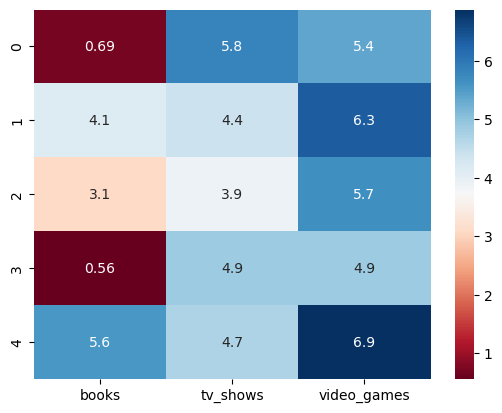

In [27]:
# view the cluster centers in a heatmap
sns.heatmap(cluster_centers5, cmap='RdBu', annot=True);

A lot of the clusters are similar, and we could potentially combine some clusters together (note: this would give us a different result than if we did 3 clusters).

**Conclusion**: 3 clusters seem to capture patterns in the data, without being too complex. This is our best model for now.

Remember our 3 clusters:

* Cluster 0: **Non-readers**
* Cluster 1: **Entertainment enthusiasts**
* Cluster 2: **Prefer video games to books**

## 3. Tune the K-Means Model

In [28]:
# read in the prepped data (engineered and standardized features) from the last section
data_v2 = pd.read_pickle('../Data/entertainment_data_for_modeling.pkl')
data_v2.head()

entertainment,video_game_lover,total_entertainment,pct_screen
0,-0.294884,-1.360056,1.384262
1,-0.294884,-1.551591,1.918235
2,-0.294884,-1.336114,1.388865
3,-0.294884,0.435582,-0.344126
4,-0.294884,-0.258731,-0.217658


In [29]:
# create 2 - 15 clusters, and add the inertia scores to the list
inertia_values_v2 = []

for k in range(2, 16):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(data_v2)
    inertia_values_v2.append(kmeans.inertia_)

C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have

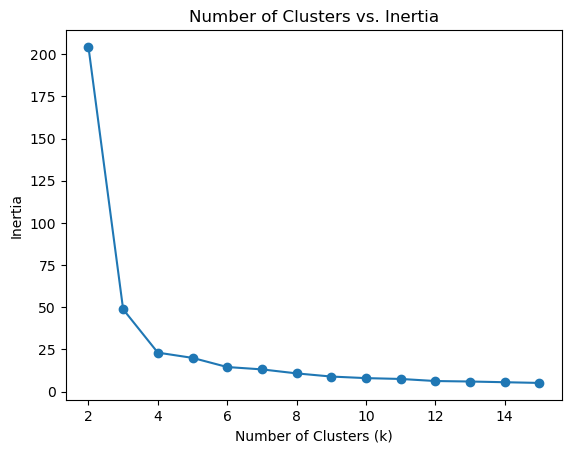

In [30]:
# plot the inertia values

# turn the list into a series for plotting
inertia_series_v2 = pd.Series(inertia_values_v2, index=range(2, 16))

# plot the data
inertia_series_v2.plot(marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Number of Clusters vs. Inertia");

In [31]:
# let's try 4 clusters
kmeans4 = KMeans(n_clusters=4, n_init='auto', random_state=42)
kmeans4.fit(data_v2)

C:\Users\Abdul Qudus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


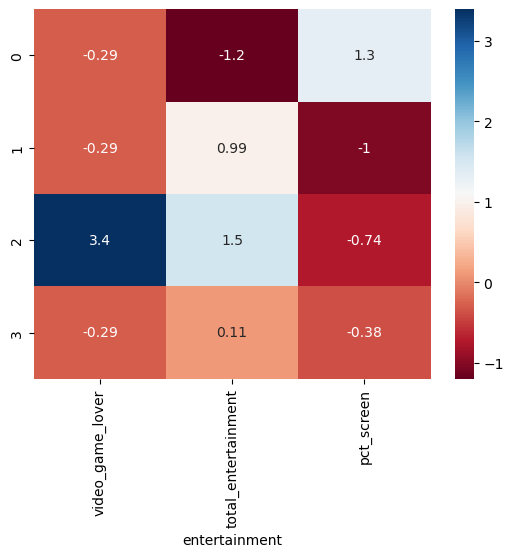

In [32]:
# view the cluster centers in a heatmap
cluster_centers4_v2 = pd.DataFrame(kmeans4.cluster_centers_, columns=data_v2.columns)
sns.heatmap(cluster_centers4_v2, cmap='RdBu', annot=True);

Name the clusters:

* Cluster 0: **Less entertainment, especially books**
* Cluster 1: **Prefer books to screens**
* Cluster 2: **Entertainment enthusiasts, especially video games**
* Cluster 3: **Typical students**

In [33]:
# view some students from cluster 0 - few books
data[kmeans4.labels_==0].head()

,books,tv_shows,video_games
0,0.5,4.6,4.9
1,0.0,4.5,4.8
2,0.5,4.5,5.0
8,0.0,4.6,4.9
11,0.5,4.8,4.7


In [34]:
# view some students from cluster 2 - lots of video games
data[kmeans4.labels_==2].head()

,books,tv_shows,video_games
19,5.8,3.9,7.7
29,6.2,5.4,7.2
31,4.5,4.4,7.3
49,5.0,4.2,7.7
50,5.2,4.5,7.1


## 4. Select the Best K-Means Model

### a. Comparing cluster assignments

The three clusters created from the original data set (books, tv_shows, movies):
* Cluster 0: **Non-readers**
* Cluster 1: **Entertainment enthusiasts**
* Cluster 2: **Prefer video games to books**

The four clusters created from the updated data set (video_game_lover, total_entertainmnet, pct_screen):
* Cluster 0: **Less entertainment, especially books**
* Cluster 1: **Prefer books to screens**
* Cluster 2: **Entertainment enthusiasts, especially video games**
* Cluster 3: **Typical students**

In [35]:
model_1_clusters = pd.Series(kmeans3.labels_, name="model_1_clusters")
model_1_names = model_1_clusters.map({0: "Non-Readers", 1: "Entertainment Enthusiasts", 2: "Prefers Video Games to Books"})

In [36]:
model_1_names

0                       Non-Readers
1                       Non-Readers
2                       Non-Readers
3      Prefers Video Games to Books
4      Prefers Video Games to Books
                   ...             
145       Entertainment Enthusiasts
146       Entertainment Enthusiasts
147       Entertainment Enthusiasts
148                     Non-Readers
149                     Non-Readers
Name: model_1_clusters, Length: 150, dtype: object

In [37]:
model_2_clusters = pd.Series(kmeans4.labels_, name="model_2_clusters")
model_2_names = model_2_clusters.map({0: "Less Entertainment, espacially books", 1: "Prefers books to screens", 
                                      2: "Entertainment Enthusiasts, espacially video games", 3: "Typical students"})

In [38]:
model_2_names

0                   Less Entertainment, espacially books
1                   Less Entertainment, espacially books
2                   Less Entertainment, espacially books
3                                       Typical students
4                                       Typical students
                             ...                        
145                             Prefers books to screens
146                             Prefers books to screens
147    Entertainment Enthusiasts, espacially video games
148                 Less Entertainment, espacially books
149                 Less Entertainment, espacially books
Name: model_2_clusters, Length: 150, dtype: object

### b. Comparing individual rows within the clusters

In [39]:
model_1_names.value_counts()

model_1_clusters
Prefers Video Games to Books    52
Non-Readers                     50
Entertainment Enthusiasts       48
Name: count, dtype: int64

In [40]:
model_2_names.value_counts()

model_2_clusters
Typical students                                     52
Less Entertainment, espacially books                 50
Prefers books to screens                             36
Entertainment Enthusiasts, espacially video games    12
Name: count, dtype: int64

In [41]:
cluster_names = pd.concat([df, model_1_names, model_2_names], axis=1)
cluster_names.head()

,name,books,tv_shows,video_games,model_1_clusters,model_2_clusters
0,Aaliyah,0.5,4.6,4.9,Non-Readers,"Less Entertainment, espacially books"
1,Abigail,0.0,4.5,4.8,Non-Readers,"Less Entertainment, espacially books"
2,Addison,0.5,4.5,5.0,Non-Readers,"Less Entertainment, espacially books"
3,Adeline,3.5,4.5,6.6,Prefers Video Games to Books,Typical students
4,Alana,2.8,3.8,5.6,Prefers Video Games to Books,Typical students


In [42]:
(cluster_names.groupby
    (["model_1_clusters", "model_2_clusters"])
    [["books", "tv_shows", "video_games"]].mean())

books  \
model_1_clusters             model_2_clusters                                              
Entertainment Enthusiasts    Entertainment Enthusiasts, espacially video games  5.125000   
                             Prefers books to screens                           5.150000   
Non-Readers                  Less Entertainment, espacially books               0.596000   
Prefers Video Games to Books Typical students                                   3.313462   

                                                                                tv_shows  \
model_1_clusters             model_2_clusters                                              
Entertainment Enthusiasts    Entertainment Enthusiasts, espacially video games  4.691667   
                             Prefers books to screens                           4.472222   
Non-Readers                  Less Entertainment, espacially books               5.130000   
Prefers Video Games to Books Typical students                                   4.117308   

                                                                                video_games  
model_1_clusters             model_2_clusters                                                
Entertainment Enthusiasts    Entertainment Enthusiasts, espacially video games     7.475000  
                             Prefers books to screens                              6.361111  
Non-Readers                  Less Entertainment, espacially books                  5.006000  
Prefers Video Games to Books Typical students                                      5.913462

## 5. Hierarchical Clustering

### a. Hierarchical clustering on the original data

In [43]:
# view the data
data

,books,tv_shows,video_games
0,0.5,4.6,4.9
1,0.0,4.5,4.8
2,0.5,4.5,5.0
3,3.5,4.5,6.6
4,2.8,3.8,5.6
...,...,...,...
145,5.2,4.6,6.9
146,6.0,4.6,6.7
147,5.5,5.7,7.7
148,0.0,6.1,5.2


In [44]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [45]:
linkage(data, method="ward")

array([[1.10000000e+01, 1.12000000e+02, 0.00000000e+00, 2.00000000e+00],
       [4.80000000e+01, 8.70000000e+01, 0.00000000e+00, 2.00000000e+00],
       [4.30000000e+01, 6.60000000e+01, 0.00000000e+00, 2.00000000e+00],
       [7.20000000e+01, 8.90000000e+01, 0.00000000e+00, 2.00000000e+00],
       [4.40000000e+01, 1.43000000e+02, 0.00000000e+00, 2.00000000e+00],
       [0.00000000e+00, 8.40000000e+01, 1.00000000e-01, 2.00000000e+00],
       [7.70000000e+01, 1.38000000e+02, 1.00000000e-01, 2.00000000e+00],
       [7.00000000e+00, 5.30000000e+01, 1.00000000e-01, 2.00000000e+00],
       [2.60000000e+01, 8.30000000e+01, 1.00000000e-01, 2.00000000e+00],
       [1.70000000e+01, 9.90000000e+01, 1.00000000e-01, 2.00000000e+00],
       [9.00000000e+01, 1.24000000e+02, 1.00000000e-01, 2.00000000e+00],
       [1.60000000e+01, 5.40000000e+01, 1.00000000e-01, 2.00000000e+00],
       [3.40000000e+01, 7.30000000e+01, 1.00000000e-01, 2.00000000e+00],
       [1.30000000e+01, 6.20000000e+01, 1.00000000e

In [46]:
linkage(data, method="ward").shape

(149, 4)

Text(0, 0.5, 'Euclidean Distance')

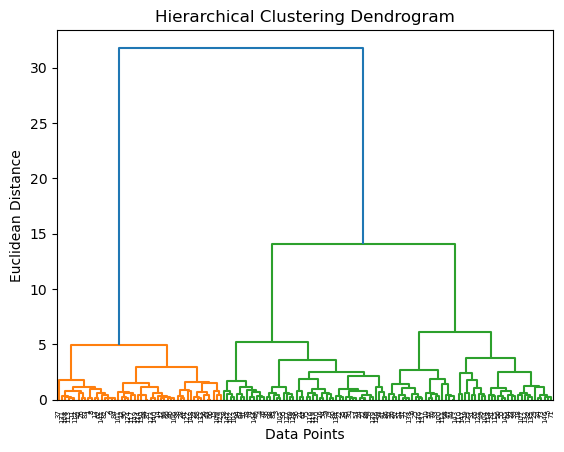

In [47]:
linkage_matrix = linkage(data, method="ward")
dendrogram_info = dendrogram(linkage_matrix)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")

Text(0, 0.5, 'Euclidean Distance')

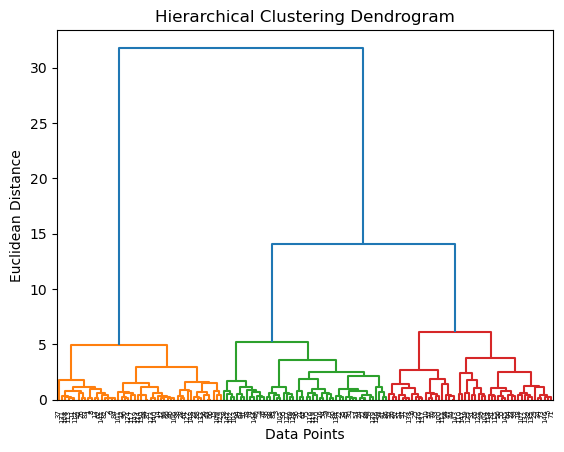

In [48]:
linkage_matrix = linkage(data, method="ward")
dendrogram_info = dendrogram(linkage_matrix, color_threshold=10)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")

In [49]:
from sklearn.cluster import AgglomerativeClustering

In [50]:
agg = AgglomerativeClustering(3)
agg.fit(data)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [51]:
agg.labels_

array([1, 1, 1, 2, 2, 0, 0, 2, 1, 2, 0, 1, 1, 1, 1, 1, 2, 1, 0, 0, 0, 2,
       2, 0, 2, 0, 1, 1, 1, 0, 2, 0, 0, 0, 0, 2, 2, 1, 1, 0, 2, 2, 1, 1,
       0, 2, 1, 0, 1, 0, 0, 0, 0, 2, 2, 0, 1, 0, 2, 2, 1, 1, 1, 2, 0, 0,
       1, 2, 0, 2, 0, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 1, 1, 1, 2, 2, 1,
       1, 2, 1, 2, 0, 2, 2, 2, 2, 0, 2, 1, 0, 1, 2, 2, 0, 2, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 2, 1, 0, 2, 2, 0, 1, 1, 1, 0, 2, 2, 2, 1, 1, 1,
       0, 1, 2, 0, 0, 0, 0, 2, 1, 1, 2, 0, 2, 0, 0, 0, 1, 1])

In [52]:
from collections import Counter

In [53]:
Counter(agg.labels_)

Counter({np.int64(1): 50, np.int64(2): 50, np.int64(0): 50})

### b. Hierarchical clustering on the engineered data

In [54]:
# view the data
data_v2

entertainment,video_game_lover,total_entertainment,pct_screen
0,-0.294884,-1.360056,1.384262
1,-0.294884,-1.551591,1.918235
2,-0.294884,-1.336114,1.388865
3,-0.294884,0.435582,-0.344126
4,-0.294884,-0.258731,-0.217658
...,...,...,...
145,-0.294884,1.177779,-0.971503
146,-0.294884,1.369314,-1.299596
147,3.391165,2.015743,-0.720344
148,-0.294884,-1.048812,1.918235


Text(0, 0.5, 'Euclidean Distance')

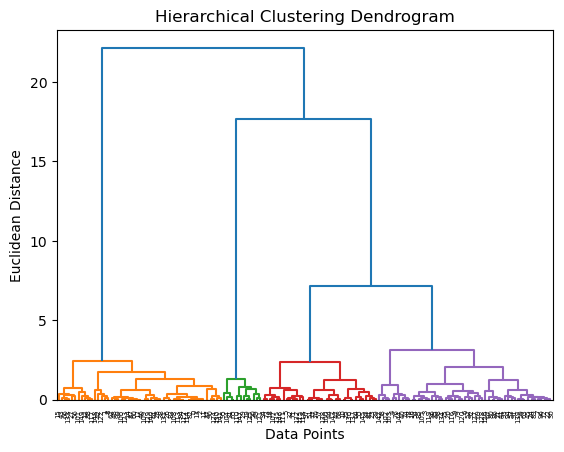

In [55]:
linkage_matrix = linkage(data_v2, method="ward")
dendrogram_info = dendrogram(linkage_matrix, color_threshold=5)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")

In [56]:
agg_v2 = AgglomerativeClustering(4)
agg_v2.fit(data_v2)

,n_clusters,4
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [57]:
agg_v2.labels_

array([1, 1, 1, 0, 0, 3, 0, 0, 1, 0, 3, 1, 1, 1, 1, 1, 0, 1, 3, 2, 0, 0,
       0, 3, 0, 3, 1, 1, 1, 2, 0, 2, 3, 3, 3, 0, 0, 1, 1, 3, 0, 0, 1, 1,
       3, 0, 1, 3, 1, 2, 2, 3, 0, 0, 0, 3, 1, 3, 0, 0, 1, 1, 1, 0, 3, 2,
       1, 0, 3, 0, 3, 3, 0, 3, 0, 0, 0, 3, 0, 0, 0, 3, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 2, 0, 3, 0, 1, 3, 1, 0, 0, 2, 0, 1, 3, 1, 1,
       2, 3, 1, 1, 1, 3, 0, 1, 3, 0, 0, 2, 1, 1, 1, 2, 0, 0, 0, 1, 1, 1,
       3, 1, 0, 3, 3, 3, 3, 0, 1, 1, 0, 3, 0, 3, 3, 2, 1, 1])

In [58]:
Counter(agg_v2.labels_)

Counter({np.int64(0): 53, np.int64(1): 50, np.int64(3): 35, np.int64(2): 12})

### c. View the cluster assignments from the visualizations

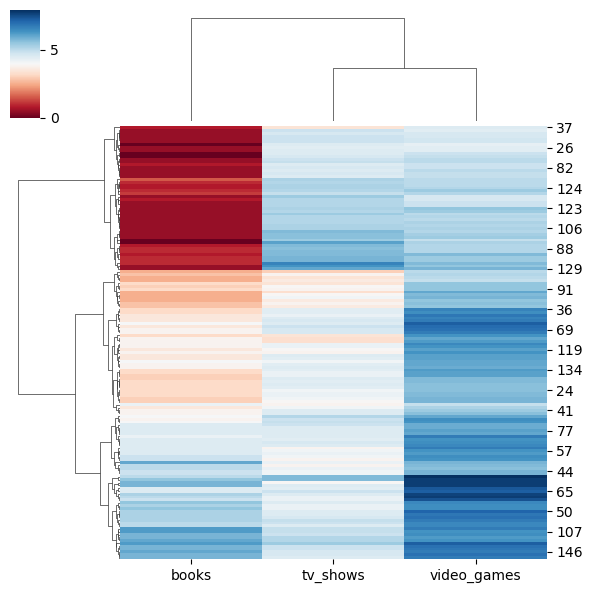

In [59]:
sns.clustermap(data, method="ward", cmap="RdBu", figsize=(6,6), xticklabels=data.columns)

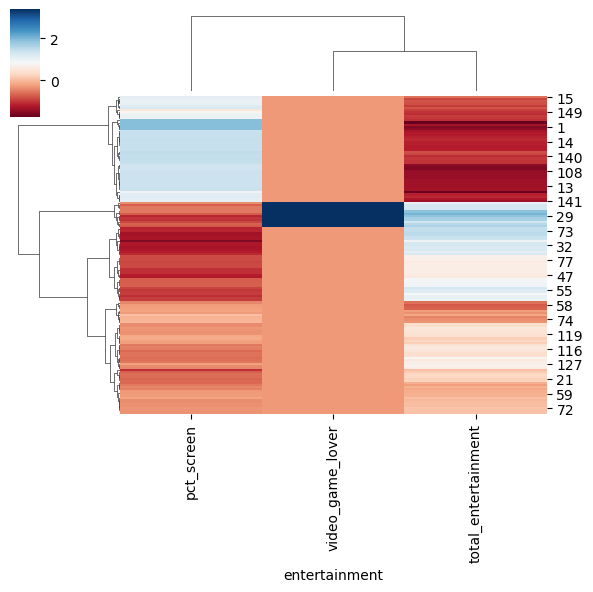

In [60]:
sns.clustermap(data_v2, method="ward", cmap="RdBu", figsize=(6,6), xticklabels=data_v2.columns)

Cluster 1: -Entertainment

Cluster 2: +Video Games

Cluster 3: +Books

Cluster 4: Typical Students

Text(0, 0.5, 'Euclidean Distance')

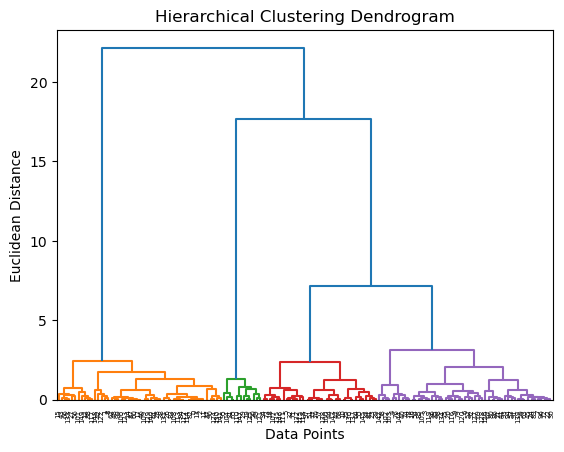

In [61]:
linkage_matrix_v2 = linkage(data_v2, method="ward")
dendrogram_info_v2 = dendrogram(linkage_matrix, color_threshold=5)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")

In [62]:
data_points = pd.Series(dendrogram_info_v2["ivl"], name="Data Point").astype(int)
data_points

0       15
1       43
2       66
3      133
4       27
      ... 
145      7
146     96
147     72
148     22
149     30
Name: Data Point, Length: 150, dtype: int64

In [63]:
from scipy.cluster.hierarchy import fcluster

In [64]:
den_clusters = pd.Series(fcluster(linkage_matrix_v2, 5, criterion="distance"), name="Dendrogram Cluster")
den_clusters

0      1
1      1
2      1
3      4
4      4
      ..
145    3
146    3
147    2
148    1
149    1
Name: Dendrogram Cluster, Length: 150, dtype: int32

In [65]:
den_clusters_df = den_clusters.reset_index()
den_clusters_df.columns=["Data Point", "Dendrogram Cluster"]
den_clusters_df

,Data Point,Dendrogram Cluster
0,0,1
1,1,1
2,2,1
3,3,4
4,4,4
...,...,...
145,145,3
146,146,3
147,147,2
148,148,1


In [66]:
den_clusters_df.sort_values(["Dendrogram Cluster", "Data Point"])

,Data Point,Dendrogram Cluster
0,0,1
1,1,1
2,2,1
8,8,1
11,11,1
...,...,...
128,128,4
134,134,4
139,139,4
142,142,4


In [67]:
den_clusters_df["Dendrogram Cluster"].value_counts()

Dendrogram Cluster
4    53
1    50
3    35
2    12
Name: count, dtype: int64

## 6. DBSCAN

### a. DBSCAN Basics

In [68]:
# import dbscan from sklearn
from sklearn.cluster import DBSCAN

In [69]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

In [70]:
dbscan.fit(data)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [71]:
dbscan.labels_

array([ 0, -1,  0,  1,  1,  1,  1,  1,  0,  1, -1,  0,  0,  0,  0, -1,  1,
        0,  1, -1,  1, -1,  1,  1,  1,  1,  0,  0,  0, -1,  1, -1,  1,  1,
        1,  1,  1, -1,  0,  1,  1,  1, -1,  0, -1,  1,  0, -1,  0, -1,  1,
        1, -1,  1,  1,  1,  0,  1, -1,  1,  0,  0,  0,  1,  1, -1,  0, -1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  0,  0,  0,
        1,  1,  0,  0,  1,  0,  1,  1,  1,  1,  1, -1,  1,  1,  0,  1,  0,
       -1,  1, -1,  1,  0,  1,  0, -1, -1, -1,  0,  0,  0,  1,  1,  0,  1,
        1,  1, -1, -1,  0,  0, -1, -1,  1,  1,  0,  0,  0,  1,  0,  1,  1,
        1,  1,  1,  1,  0,  0,  1, -1,  1,  1,  1, -1, -1,  0])

In [72]:
n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_clusters

2

In [73]:
from sklearn.metrics import silhouette_score

In [74]:
silhouette_score(data, dbscan.labels_, metric="euclidean", sample_size=None)

0.3419620951011187

### b. DBSCAN Steps within a Function

In [75]:
results = []

eps_values = np.arange(.1, 2, .1)
min_samples_values = np.arange(2, 10, 1)

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(data)
        labels = dbscan.labels_

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            silhouette = silhouette_score(data, labels, metric="euclidean", sample_size=None)
        else:
            silhouette = None

        results.append([eps, min_samples, n_clusters, n_noise, silhouette])

dbscan_results = pd.DataFrame(results, columns=["Eps", "Minimum Samples", "Number of Clusters",
                                               "Number of Noise Points", "Silhouette Score"])
dbscan_results

,Eps,Minimum Samples,Number of Clusters,Number of Noise Points,Silhouette Score
0,0.1,2,12,124,-0.438782
1,0.1,3,2,144,-0.483479
2,0.1,4,0,150,NaN
3,0.1,5,0,150,NaN
4,0.1,6,0,150,NaN
...,...,...,...,...,...
147,1.9,5,1,0,NaN
148,1.9,6,1,0,NaN
149,1.9,7,1,0,NaN
150,1.9,8,1,0,NaN


In [76]:
dbscan_results.sort_values("Silhouette Score", ascending=False).groupby("Silhouette Score").head(1).head()

,Eps,Minimum Samples,Number of Clusters,Number of Noise Points,Silhouette Score
109,1.4,7,2,0,0.628673
77,1.0,7,2,2,0.550831
66,0.9,4,2,3,0.528540
72,1.0,2,2,1,0.515323
57,0.8,3,2,4,0.497686


In [77]:
def tune_dbscan(data):

    results = []
    
    eps_values = np.arange(.1, 2, .1)
    min_samples_values = np.arange(2, 10, 1)
    
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            dbscan.fit(data)
            labels = dbscan.labels_
    
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
            n_noise = list(labels).count(-1)
    
            if n_clusters > 1:
                silhouette = silhouette_score(data, labels, metric="euclidean", sample_size=None)
            else:
                silhouette = None
    
            results.append([eps, min_samples, n_clusters, n_noise, silhouette])
    
    dbscan_results = pd.DataFrame(results, columns=["Eps", "Minimum Samples", "Number of Clusters",
                                                   "Number of Noise Points", "Silhouette Score"])
    return dbscan_results

In [78]:
dbscan_results_1 = tune_dbscan(data)
dbscan_results_1.head()

,Eps,Minimum Samples,Number of Clusters,Number of Noise Points,Silhouette Score
0,0.1,2,12,124,-0.438782
1,0.1,3,2,144,-0.483479
2,0.1,4,0,150,NaN
3,0.1,5,0,150,NaN
4,0.1,6,0,150,NaN


In [79]:
dbscan_results_2 = tune_dbscan(data_v2)
dbscan_results_2.head()

,Eps,Minimum Samples,Number of Clusters,Number of Noise Points,Silhouette Score
0,0.1,2,25,36,0.209512
1,0.1,3,14,58,0.080184
2,0.1,4,8,84,-0.072472
3,0.1,5,5,97,-0.130030
4,0.1,6,4,104,-0.188572


In [80]:
dbscan_results_1.sort_values("Silhouette Score", ascending=False).groupby("Silhouette Score").head(1).head()

,Eps,Minimum Samples,Number of Clusters,Number of Noise Points,Silhouette Score
109,1.4,7,2,0,0.628673
77,1.0,7,2,2,0.550831
66,0.9,4,2,3,0.528540
72,1.0,2,2,1,0.515323
57,0.8,3,2,4,0.497686


In [81]:
dbscan_results_2.sort_values("Silhouette Score", ascending=False).groupby("Silhouette Score").head(1).head()

,Eps,Minimum Samples,Number of Clusters,Number of Noise Points,Silhouette Score
50,0.7,4,3,0,0.734752
38,0.5,8,3,3,0.691331
29,0.4,7,3,7,0.654354
27,0.4,5,3,6,0.652730
121,1.6,3,2,0,0.647356


In [82]:
dbscan_v2 = DBSCAN(eps=0.6, min_samples=7)
dbscan_v2.fit(data)
dbscan_v2.labels_

array([ 0,  0,  0,  1,  1,  1,  1,  1,  0,  1,  1,  0,  0,  0,  0, -1,  1,
        0,  1, -1,  1,  1,  1,  1,  1,  1,  0,  0,  0, -1,  1, -1,  1,  1,
        1,  1,  1, -1,  0,  1,  1,  1,  0,  0,  1,  1,  0,  1,  0, -1,  1,
        1,  1,  1,  1,  1,  0,  1, -1,  1,  0,  0,  0,  1,  1, -1,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,  0,
        1,  1,  0,  0,  1,  0,  1,  1,  1,  1,  1, -1,  1,  1,  0,  1,  0,
        1,  1, -1,  1,  0,  1,  0, -1, -1, -1,  0,  0,  0,  1,  1,  0,  1,
        1,  1, -1,  0,  0,  0, -1, -1,  1,  1,  0,  0,  0,  1,  0,  1,  1,
        1,  1,  1,  1,  0,  0,  1,  1,  1,  1,  1, -1, -1,  0])

## 7. Comparing Models

In [83]:
kmeans4

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [84]:
agg_v2

,n_clusters,4
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [85]:
dbscan_v2

,eps,0.6
,min_samples,7
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [86]:
pd.Series(kmeans4.labels_).value_counts()

3    52
0    50
1    36
2    12
Name: count, dtype: int64

In [87]:
pd.Series(agg_v2.labels_).value_counts()

0    53
1    50
3    35
2    12
Name: count, dtype: int64

In [88]:
pd.Series(dbscan_v2.labels_).value_counts()

 1    86
 0    46
-1    18
Name: count, dtype: int64

In [89]:
silhouette_score(data_v2, kmeans4.labels_)

0.6391928370218308

In [90]:
silhouette_score(data_v2, agg_v2.labels_)

0.6368911098386921

In [91]:
silhouette_score(data_v2, dbscan_v2.labels_)

0.5952312367738413

Silhouette Score close to 1 is best.

## 8. Labelling Unseen Data

In [92]:
ent = pd.read_excel("../Data/entertainment.xlsx")

In [94]:
ent = ent.pivot(index="name", columns="entertainment", values="hours_per_week").reset_index()
ent = ent.fillna(0)
ent.head()

entertainment,name,books,movies,tv_shows,video_games
0,Aaliyah,0.5,1.5,4.6,4.9
1,Abigail,0.0,1.4,4.5,4.8
2,Addison,0.5,1.6,4.5,5.0
3,Adeline,3.5,4.4,4.5,6.6
4,Alana,2.8,3.9,3.8,5.6


In [116]:
ent["video_game_lover"] = np.where(ent["video_games"] > 7, 1, 0)
ent["total_entertainment"] = ent.books + ent.movies + ent.tv_shows + ent.video_games
ent["pct_screen"] = (ent.movies + ent.tv_shows + ent.video_games) / ent.total_entertainment
ent.head()

entertainment,name,books,movies,tv_shows,video_games,video_game_lover,total_entertainment,pct_screen
0,Aaliyah,0.5,1.5,4.6,4.9,0,11.5,0.956522
1,Abigail,0.0,1.4,4.5,4.8,0,10.7,1.000000
2,Addison,0.5,1.6,4.5,5.0,0,11.6,0.956897
3,Adeline,3.5,4.4,4.5,6.6,0,19.0,0.815789
4,Alana,2.8,3.9,3.8,5.6,0,16.1,0.826087


In [117]:
ent_subset = ent[["video_game_lover", "total_entertainment", "pct_screen"]]
ent_subset.head()

entertainment,video_game_lover,total_entertainment,pct_screen
0,0,11.5,0.956522
1,0,10.7,1.000000
2,0,11.6,0.956897
3,0,19.0,0.815789
4,0,16.1,0.826087


In [118]:
from sklearn.preprocessing import StandardScaler

In [121]:
std_scaler = StandardScaler()
standardized = std_scaler.fit_transform(ent_subset)
ent_scaled = pd.DataFrame(standardized, columns=ent_subset.columns)
ent_scaled.head()

entertainment,video_game_lover,total_entertainment,pct_screen
0,-0.294884,-1.360056,1.384262
1,-0.294884,-1.551591,1.918235
2,-0.294884,-1.336114,1.388865
3,-0.294884,0.435582,-0.344126
4,-0.294884,-0.258731,-0.217658


In [123]:
student1 = pd.DataFrame([np.array([0,0,0,0])], columns=["books", "movies", "tv_shows", "video_games"])

In [124]:
student2 = pd.DataFrame([np.array([3,3.8,4.6,5.8])], columns=["books", "movies", "tv_shows", "video_games"])

In [125]:
student1

,books,movies,tv_shows,video_games
0,0,0,0,0


In [126]:
student2

,books,movies,tv_shows,video_games
0,3.0,3.8,4.6,5.8


In [140]:
def prep_student_data(ent):
    ent["video_game_lover"] = np.where(ent["video_games"] > 7, 1, 0)
    ent["total_entertainment"] = ent.books + ent.movies + ent.tv_shows + ent.video_games
    ent["pct_screen"] = (ent.movies + ent.tv_shows + ent.video_games) / ent.total_entertainment
    ent=ent.fillna(0)
    
    ent_subset = ent[["video_game_lover", "total_entertainment", "pct_screen"]]
    
    ent_scaled = std_scaler.transform(ent_subset)
    
    ent_prepped = pd.DataFrame(ent_scaled, columns=ent_subset.columns)

    return ent_prepped

In [141]:
prep_student_data(student1)

,video_game_lover,total_entertainment,pct_screen
0,-0.294884,-4.113368,-10.363153


In [142]:
prep_student_data(student2)

,video_game_lover,total_entertainment,pct_screen
0,-0.294884,0.004629,-0.223867


4 Cluster from the K-Means model:

Cluster 0: Less entertainment, espacially books

Cluster 1: Less Screens

Cluster 2: Entertainment Enthusiasts, espacially video games

Cluster 3: Typical Students

In [143]:
kmeans4

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [145]:
kmeans4.predict(prep_student_data(student1))

array([1], dtype=int32)

In [146]:
kmeans4.predict(prep_student_data(student2))

array([3], dtype=int32)